<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/week_06_boosting_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello")

hello


# Module 20: AdaBoost (Adaptive Boosting)

## 1. Libraries and Tools
We first import all required libraries. Each library is chosen intentionally.


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

## 2. Loading the Dataset
We use the Breast Cancer dataset because it is clean, binary, and well-suited for demonstrating boosting behavior.

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


## 3. Train-Test Split
We split the dataset so that evaluation is fair and unbiased.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 426
Testing samples: 143


## 4. Baseline Model: Decision Stump
Before boosting, we examine how a single weak learner performs.

In [ ]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
# WEAK LEARNER kei amra short e stump boli
stump.fit(X_train, y_train)
y_pred_stump = stump.predict(X_test)
print('Decision Stump Accuracy:', accuracy_score(y_test, y_pred_stump))

Decision Stump Accuracy: 0.8951048951048951


## 5. Building AdaBoost Model
Now we boost the weak learner using AdaBoost.

In [ ]:
# building adaboost model
base_learner = DecisionTreeClassifier(max_depth = 1, random_state =42)

ada = AdaBoostClassifier(
    estimator= base_learner,
    n_estimators=100,
    learning_rate=0.3,
    random_state=42
)

ada.fit(X_train, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.3, n_estimators=100, random_state=42)

**AdaBoostClassifier**

class sklearn.ensemble.AdaBoostClassifier(estimator=None, *, n_estimators=50, learning_rate=1.0, random_state=None)

**Parameters:**
* estimator: object, default=None

The base estimator from which the boosted ensemble is built. Support for sample weighting is required, as well as proper classes_ and n_classes_ attributes. If None, then the base estimator is DecisionTreeClassifier initialized with max_depth=1.

* n_estimatorsint, default=50

The maximum number of estimators at which boosting is terminated. In case of perfect fit, the learning procedure is stopped early. Values must be in the range [1, inf).

* learning_rate: float, default=1.0

Weight applied to each classifier at each boosting iteration. A higher learning rate increases the contribution of each classifier. There is a trade-off between the learning_rate and n_estimators parameters. Values must be in the range (0.0, inf).

* random_state: int, RandomState instance or None, default=None

Controls the random seed given at each estimator at each boosting iteration. Thus, it is only used when estimator exposes a random_state. Pass an int for reproducible output across multiple function calls

## 6. Predictions
AdaBoost makes predictions using a weighted vote of weak learners.

In [ ]:
#Predictions
y_pred_ada = ada.predict(X_test)
print('AdaBoost Accuracy: ', accuracy_score(y_test, y_pred_ada))

AdaBoost Accuracy:  0.958041958041958


## 7. Detailed Evaluation
Accuracy alone is not enough. We use additional metrics.

In [ ]:
print(classification_report(y_test, y_pred_ada))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143

Confusion Matrix:
 [[51  3]
 [ 3 86]]


## 8. Effect of Number of Estimators (n_estimators)
We now observe how the number of weak learners affects performance.

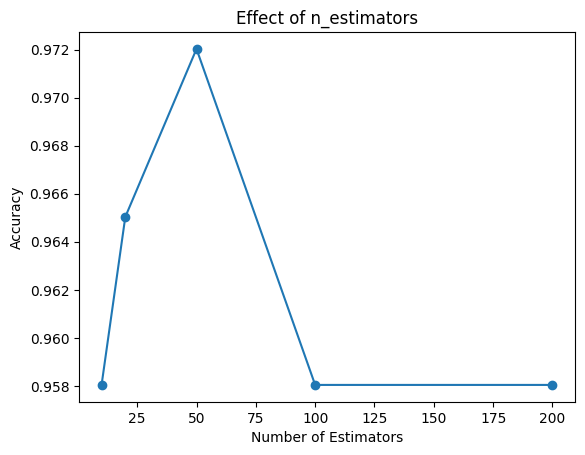

In [ ]:
# Effect of number of estimators
estimators = [10, 20, 50, 100, 200]
accs = []

for n in estimators:
  model = AdaBoostClassifier(
      estimator = base_learner,
      n_estimators = n,
      learning_rate = 0.3,
      random_state = 42
  )
  model.fit(X_train, y_train)
  accs.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(estimators, accs, marker = 'o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title("Effect of n_estimators")
plt.show()

## 9. Effect of Learning Rate
Learning rate controls how strongly each learner contributes.

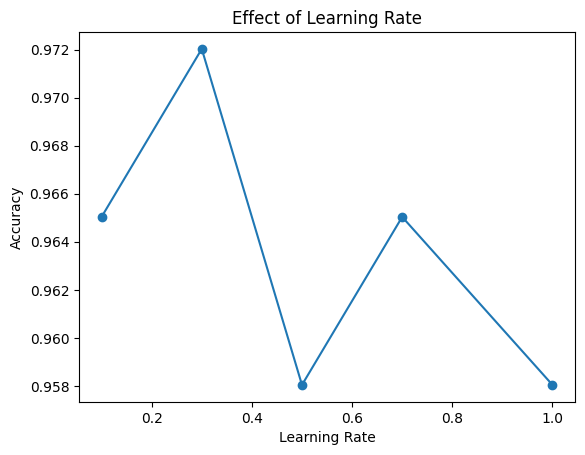

In [ ]:
# Effect of number of estimators
rates = [0.1, 0.3, 0.5, 0.7, 1.0]
accs = []

for lr in rates:
  model = AdaBoostClassifier(
      estimator = base_learner,
      n_estimators = 50,
      learning_rate = lr,
      random_state = 42
  )
  model.fit(X_train, y_train)
  accs.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(rates, accs, marker = 'o')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title("Effect of Learning Rate")
plt.show()

## 10. GridSearchCV
We can try to find the optimal parameters through GridSearchCV here.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for AdaBoost
param_grid = {
    'n_estimators': [20, 50, 100, 200],
    'learning_rate': [0.1, 0.3, 0.5, 0.7, 1.0],
    'estimator__max_depth': [1, 2]
}

# GridSearchCV setup
grid = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=base_learner,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Run grid search
grid.fit(X_train, y_train)

# Best model evaluation
best_model = grid.best_estimator_
y_pred_grid = best_model.predict(X_test)

print("Best Parameters Found:")
print(grid.best_params_)
print("\nTest Accuracy (GridSearch AdaBoost):",
      accuracy_score(y_test, y_pred_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid))

Best Parameters Found:
{'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 200}

Test Accuracy (GridSearch AdaBoost): 0.9790209790209791

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## 11. Limitations and Use Cases
AdaBoost performs well on clean data but struggles with heavy noise and outliers.

### Changes you can try
1. Change max_depth to 3-6 and observe results
2. Combine low learning rate with high estimators
3. Compare AdaBoost with a full decision tree and Random Forest


# Module 21: Gradient Boosting
## Training, Implementation, Evaluation, and Overfitting Control

This notebook covers:
1. Gradient Boosting training, prediction, and key parameters
2. Implementing Gradient Boosting on a real dataset
3. Model evaluation, overfitting control, and practical use cases


## Section 1: Gradient Boosting Training, Prediction & Key Parameters

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Explanation
- NumPy and Pandas are used for numerical and tabular operations.
- Matplotlib is used for visual analysis.
- GradientBoostingRegressor is the core model used in this module.
- Mean Squared Error and R2 Score are used for regression evaluation.

In [ ]:
import pandas as pd

california_housing_url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

housing_df = pd.read_csv(california_housing_url)

# Prepare X and y
X = housing_df.drop('median_house_value', axis=1)
y = housing_df['median_house_value']

# Handle missing values
if X.isnull().sum().any():
    X = X.fillna(X.median(numeric_only=True))

print("California Housing data loaded from alternative URL.")

X.head()

California Housing data loaded from alternative URL.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [ ]:
y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


### Explanation
- California Housing is a real-world dataset with non-linear relationships.
- X contains input features.
- y is the target variable (median house value).
- Always inspect data before modeling.

In [ ]:
# Perform one-hot encoding on the 'ocean_proximity' column
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Explanation
- 80% of data is used for training.
- 20% is reserved for testing.
- Random state ensures reproducibility.
- Boosting models are sensitive to overfitting, so clean separation matters.

In [ ]:
#Model Declaration
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
y_pred = gbr.predict(X_test)

### Explanation
- n_estimators controls how many boosting steps (trees) are used.
- learning_rate controls how much each tree contributes.
- max_depth keeps trees shallow to avoid overfitting.
- Gradient Boosting prefers many weak learners.

class sklearn.ensemble.GradientBoostingRegressor(*, loss='squared_error', learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='friedman_mse', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0, init=None, random_state=None, max_features=None, alpha=0.9, verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)

Details: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html#sklearn.ensemble.GradientBoostingRegressor


### Explanation
- Predictions are generated by summing all trees with shrinkage applied.
- At this stage, boosting iterations are complete.

## Section 2: Implementing Gradient Boosting on a Dataset

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2
# mse ekhane onek beshi, but r2 ta valo asche

(3123095111.877028, 0.7616701988665029)

### Explanation
- Mean Squared Error measures average squared prediction error.
- R2 Score measures how much variance is explained by the model.
- Higher R2 and lower MSE indicate better performance.

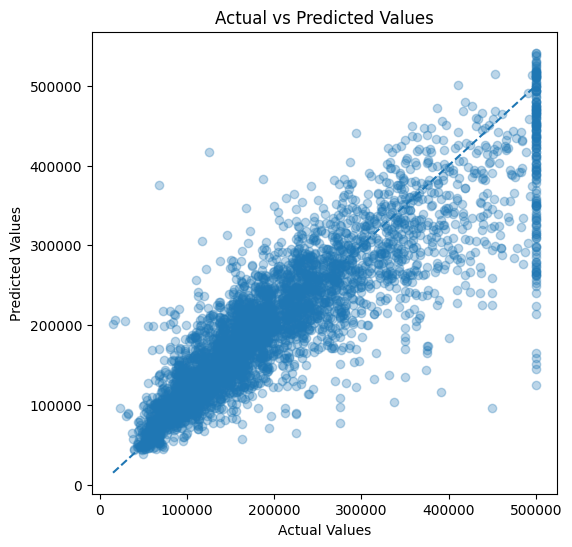

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

### Explanation
- Each point represents a prediction.
- The dashed line represents perfect prediction.
- Deviation from the line indicates prediction error.

## Section 3: Model Evaluation, Overfitting Control & Use Cases

###3.1 Understanding Overfitting in Gradient Boosting

Explain verbally before coding:

* Too many trees can overfit.

* Too large learning rate can overshoot.

* Deep trees learn noise.

###3.2 Effect of Learning Rate

In [ ]:
#Effect of Learning Rate

"""
Too large learning rate = model takes steps that are too big and may go past the best solution, making training unstable or less accurate.
"""
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.8]
results = []

for lr in learning_rates:
  model = GradientBoostingRegressor(
      n_estimators=100,
      learning_rate=lr,
      max_depth = 3,
      random_state = 42

  )
  model.fit(X_train, y_train)
  preds = model.predict(X_test)
  results.append((lr, r2_score(y_test, preds)))

pd.DataFrame(results, columns=["Learning Rate", "R2 Score"])

,Learning Rate,R2 Score
0,0.01,0.507628
1,0.05,0.705390
2,0.10,0.761670
3,0.20,0.788948
4,0.80,0.793571


### Explanation
- Smaller learning rates require more trees.
- Larger learning rates may overfit.
- This demonstrates the bias-variance tradeoff.

###3.3 Effect of Tree Depth

In [ ]:
#Effect of Tree Depth
depths = [1,2,3,4,7]
results = []

for depth in depths:
  model = GradientBoostingRegressor(
      n_estimators=100,
      learning_rate=0.1,
      max_depth = depth,
      random_state = 42

  )
  model.fit(X_train, y_train)
  preds = model.predict(X_test)
  results.append((depth, r2_score(y_test, preds)))

pd.DataFrame(results, columns=["Max_Depth", "R2 Score"])

,Max_Depth,R2 Score
0,1,0.615500
1,2,0.712707
2,3,0.761670
3,4,0.791932
4,7,0.823634


###Explanation

* Shallow trees capture simple patterns.

* Deeper trees capture complex patterns but may overfit.

* Boosting works best with shallow trees.

###3.4 Feature Importance

In [ ]:
feature_importance = gbr.feature_importances_

importance_df = pd.Series(
    feature_importance, index=X.columns
).sort_values(ascending=False)

importance_df.head(10)

,0
median_income,0.588018
ocean_proximity_INLAND,0.168416
longitude,0.086303
latitude,0.048448
housing_median_age,0.041398
population,0.025039
total_bedrooms,0.021696
ocean_proximity_NEAR OCEAN,0.006269
households,0.006032
ocean_proximity_NEAR BAY,0.005186


###Explanation

- Gradient Boosting can provide feature importance.

- Higher importance means the feature was used more in splits.

- This helps interpret the model.

### 3.5 Practical Use Cases

Gradient Boosting is widely used in:

- Credit risk and loan default prediction

- Fraud detection

- Medical risk scoring

- Demand forecasting

- Ranking systems

- Tabular Kaggle competitions

If the data is structured and performance matters, Gradient Boosting is often the first serious model to try.


# Module 22: XGBoost  
## XGBoost Training, Prediction, Implementation, Evaluation & Use Cases



## 22.3 XGBoost Training, Prediction & Key Parameters

### How XGBoost Training Works (Big Picture)

XGBoost training follows a disciplined correction loop:

1. Start with an initial prediction (base score)
2. Compute gradients and hessians
3. Build a tree that minimizes the objective
4. Compute optimal leaf weights
5. Update predictions using learning rate
6. Repeat until performance stops improving

> Key idea: **Each tree is weak on purpose. Strength comes from many controlled corrections.**



### XGBoost Prediction Formula

The final prediction is:

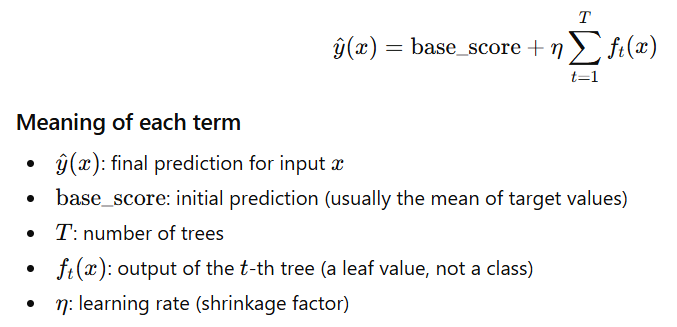\[


> Prediction is the **sum of all trees**, not the last tree.



### Key Parameters You Must Understand

#### Core Structure
- `n_estimators`: number of trees  
- `max_depth`: depth of each tree  
- `learning_rate (eta)`: step size of updates  

Golden rule:
> High depth + high learning rate = overfitting speedrun



#### Regularization Parameters (XGBoost Superpower)

- `gamma`: minimum gain required for a split
- `reg_lambda`: L2 penalty on leaf weights
- `reg_alpha`: L1 penalty (sparsity)

These prevent XGBoost from memorizing noise.



#### Sampling Parameters

- `subsample`: fraction of rows used per tree
- `colsample_bytree`: fraction of features used per tree

> Sampling intentionally hides data to reduce overfitting.



#### Objective Function

Examples:
- `reg:squarederror` → regression
- `binary:logistic` → binary classification
- `multi:softprob` → multiclass classification

> Wrong objective = wrong math = useless model



## 22.4 Implementing XGBoost on a Dataset

We will use a **binary classification dataset** so evaluation concepts are meaningful.


In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier


### Load Dataset

This dataset predicts whether a tumor is:
- 0 = malignant
- 1 = benign


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


### Train-Test Split

We use stratification to preserve class balance.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Train a Baseline XGBoost Model

This is a **sane default**, not hyperparameter tuning.


In [17]:
#Deafult XGBoost Model
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


### Prediction

- `predict` gives class labels  
- `predict_proba` gives confidence scores


In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


## 22.5 Model Evaluation, Model Selection & Practical Use Cases



### Evaluation Metrics

Accuracy alone is dangerous. Always inspect precision and recall.


In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114




### Confusion Matrix

Interpret errors, not just numbers.


In [20]:
confusion_matrix(y_test, y_pred)

array([[38,  4],
       [ 2, 70]])


### Early Stopping (Overfitting Control)

Early stopping halts training when validation performance stops improving.


In [21]:
#Early Stopping (Overfitting Control)
"""
jokhiinie amra optimal ekta ans e pouchay jabo, taile ar jawar dorkar nai
"""
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 3,
    "eta": 0.05, #this is learning rate
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42 #this is the random state
}

modelr = xgb.train(
    params = params,
    dtrain=dtrain,
    num_boost_round=500, #this is n_estimators
    evals=[(dtest,"eval")],
    early_stopping_rounds=20 #jodi value ar na kome, taile 20 bvar aro iterate koira dekhbe je value kome kina, naile offd koira dibe
)

[0]	eval-logloss:0.61976
[1]	eval-logloss:0.58516
[2]	eval-logloss:0.55188
[3]	eval-logloss:0.52339
[4]	eval-logloss:0.49845
[5]	eval-logloss:0.47458
[6]	eval-logloss:0.45356
[7]	eval-logloss:0.43314
[8]	eval-logloss:0.41336
[9]	eval-logloss:0.39494
[10]	eval-logloss:0.37949
[11]	eval-logloss:0.36460
[12]	eval-logloss:0.35192
[13]	eval-logloss:0.33671
[14]	eval-logloss:0.32416
[15]	eval-logloss:0.31177
[16]	eval-logloss:0.30187
[17]	eval-logloss:0.29179
[18]	eval-logloss:0.28017
[19]	eval-logloss:0.27033
[20]	eval-logloss:0.26235
[21]	eval-logloss:0.25466
[22]	eval-logloss:0.24639
[23]	eval-logloss:0.23927
[24]	eval-logloss:0.23303
[25]	eval-logloss:0.22664
[26]	eval-logloss:0.22033
[27]	eval-logloss:0.21575
[28]	eval-logloss:0.21105
[29]	eval-logloss:0.20664
[30]	eval-logloss:0.20204
[31]	eval-logloss:0.19800
[32]	eval-logloss:0.19291
[33]	eval-logloss:0.18865
[34]	eval-logloss:0.18429
[35]	eval-logloss:0.18066
[36]	eval-logloss:0.17764
[37]	eval-logloss:0.17402
[38]	eval-logloss:0.16

In [22]:
y_prob = modelr.predict(dtest)

y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)

Accuracy:  0.956140350877193


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [24]:
print("Early Stopping Information: ")
print("Best Iteration:", modelr.best_iteration)
print("Best score [logloss]: ", modelr.best_score)

Early Stopping Information: 
Best Iteration: 209
Best score [logloss]:  0.09239418868214432



### Feature Importance

Importance indicates contribution, not causation.


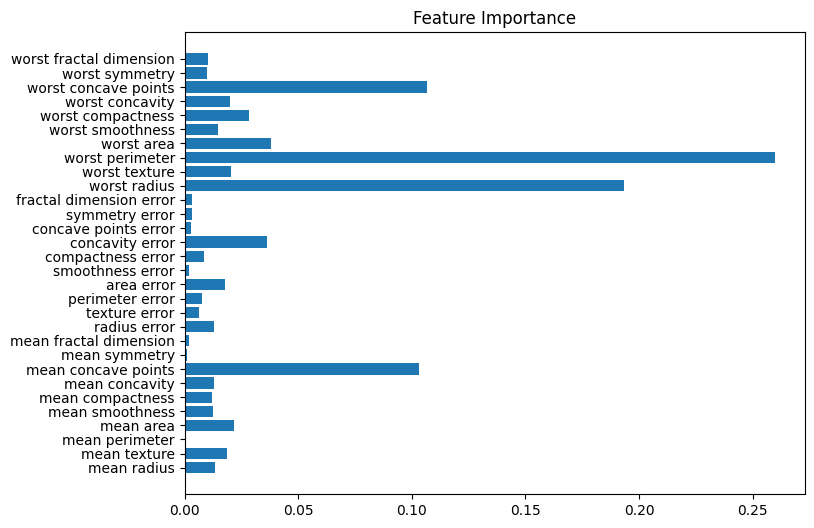

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()


### When to Use XGBoost

**Use XGBoost when:**
- Data is tabular
- Features are mixed
- Strong baseline performance is needed

**Avoid XGBoost when:**
- Dataset is extremely small
- Data is sequential or spatial
- Interpretability is the top priority



### Practical Use Cases

- Finance: credit risk, fraud detection
- Healthcare: structured diagnosis data
- Marketing: churn prediction
- Operations: demand forecasting



## Final Recap

- XGBoost is Gradient Boosting with discipline
- Regularization prevents overfitting
- Second-order optimization stabilizes learning
- Early stopping saves you from bad parameters

> XGBoost does not guess. It **calculates**.



---
## 22.6 Hyperparameter Tuning with GridSearchCV [Optional]

Until now, we used **sane default parameters**.  
In practice, we often want to systematically search for better hyperparameters.

In this section, we will:
- Tune a **small, meaningful set** of XGBoost parameters
- Use **GridSearchCV**
- Discuss *why* each parameter is included in the grid

> Important: Grid search is expensive. We keep the grid small for teaching and sanity.



### Why Not Tune Everything?

Tuning too many parameters at once:
- Explodes computation time
- Makes results hard to interpret
- Encourages blind optimization

Good practice:
> Tune depth, learning rate, number of trees, and sampling first.


In [ ]:
from sklearn.model_selection import GridSearchCV


### Define Parameter Grid

We tune only the most impactful parameters:

- `n_estimators`: number of boosting rounds  
- `max_depth`: tree complexity  
- `learning_rate`: step size  
- `subsample`: row sampling  

This keeps the search interpretable.


In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}


### Base Model for Grid Search

We keep other parameters fixed so their effects do not mix with the tuned ones.


In [ ]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False
)


### Run GridSearchCV

We use:
- 5-fold cross-validation
- Accuracy as scoring metric

Note:
> In real projects, choose metrics based on business impact, not convenience.


In [ ]:
grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:32:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=0.8, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)


### Best Parameters Found


In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV Accuracy: 0.9736263736263737



### Evaluate Tuned Model on Test Set

Always evaluate on **unseen data**.


In [ ]:
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Test Accuracy (Tuned):", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Test Accuracy (Tuned): 0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114




### Important Teaching Takeaways

- Grid search does not replace understanding
- Smaller grids are often better
- Cross-validation reduces luck-based results
- Tuned models can still overfit if evaluation is careless

> Hyperparameter tuning improves models, but **data quality improves them more**.
